In [1]:
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import fitsio as F
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import glob
import re
import healpy as hp
plt.style.use(['science', 'notebook', 'grid'])
ABACUS_PATH= '/user/shadab/globus_data/cosmosim/NFW_Abacus/'

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [3]:
cosmo = FlatLambdaCDM(H0=67.36, Om0=0.315192)
h = 0.6736
CKMS = 299792.458  # km/s

### ABacus properties
BOXSIZE = 2000.0
PMASS   = 2.109081520453063e9
MMIN    = 35 * PMASS

In [4]:
zgrid = np.linspace(0, 2, 30000)
Dc_grid = cosmo.comoving_distance(zgrid).value * h   # Mpc -> Mpc/h
z_of_Dc = interp1d(Dc_grid, zgrid)

In [5]:
ABACUS_PATH_BASE ='/user/shadab/globus_data/cosmosim/NFW_Abacus/AbacusSummit_base_c000_ph000/z0.100/'
files = glob.glob(ABACUS_PATH_BASE + 'sub_*_nsub_4.fits')
def subidx(fn):
    return int(re.search(r'sub_(\d+)_nsub', fn).group(1))

files = sorted(files, key=subidx)


In [6]:
from concurrent.futures import ThreadPoolExecutor

def read_file(f):
    return F.read(f)

with ThreadPoolExecutor() as ex:
    d = np.concatenate(list(ex.map(read_file, files)))


In [9]:
# d = d[d['Mvir'] < MMIN]
print(f"{len(d[d['Mvir'] < MMIN]):,} below resolution floor")

352 below resolution floor


In [10]:
d = d[d['Mvir'] > MMIN]
print(f"{len(d[d['Mvir'] > MMIN]):,} above resolution floor")

382,474,270 above resolution floor


In [11]:
cosmo = FlatLambdaCDM(H0=67.36, Om0=0.315192); h = 0.6736
BOX = 2000.0
zg = np.linspace(0, 2, 20000)
z_of_Dc = interp1d(cosmo.comoving_distance(zg).value*h, zg)

subidx = lambda fn: int(re.search(r'sub_(\d+)_nsub', fn).group(1))
#files  = sorted(glob.glob('.../z0.100/sub_*_nsub_4.fits'), key=subidx)


In [14]:
d

array([([1.0521851e+00, 1.1047363e-01, 2.0364136e+01], [-41.926468, 293.0638  , 343.99112 ], 1.6582443e+11, 0.18693669, 0.00777984,  88.77257 , 1.32872135e+11, 0.00841756,         0, 1.32872135e+11),
       ([1.2172241e+00, 1.5081787e-01, 2.1060852e+01], [-40.372696, 310.83276 , 351.26587 ], 1.7898509e+11, 0.19175676, 0.00383462, 103.30684 , 1.43417541e+11, 0.01804281,         1, 1.43417541e+11),
       ([4.6252441e-01, 9.4641113e-01, 2.6596375e+01], [-23.389057, 488.9866  , 590.35315 ], 1.5792803e+11, 0.18392105, 0.01067137,  79.045654, 1.26544888e+11, 0.02332098,         2, 1.26544888e+11),
       ...,
       ([1.9995176e+03, 1.9990386e+03, 1.9610670e+03], [216.02055 , 272.03958 , 113.30478 ], 1.7372083e+11, 0.18985805, 0.01184023,  83.682465, 1.39199382e+11, 0.01765927, 382474664, 1.39199382e+11),
       ([1.9999238e+03, 1.9994683e+03, 1.9611294e+03], [ 79.57176 , 209.37997 ,  79.83678 ], 8.3701852e+11, 0.32066882, 0.01455601, 149.39928 , 6.70687953e+11, 0.01674257, 382474665, 6.706

In [12]:
#rng  = np.random.default_rng(0)
#frac = 1
# chunks = []
# chunks_vel = []
# for f in files:
#     x = F.read(f, columns=['x_L2com'])['x_L2com']
#     vel = F.read(f, columns=['v_L2com'])['v_L2com']
#     keep = rng.random(len(x)) < frac
#     chunks.append(x[keep])
#     chunks_vel.append(vel[keep])


def read_pos_vel(f):
    return F.read(f, columns=['x_L2com'])['x_L2com'], F.read(f, columns=['v_L2com'])['v_L2com']

with ThreadPoolExecutor() as ex:
    pos, vel = zip(*ex.map(read_pos_vel, files))
print(f"{len(pos):,} sampled")


64 sampled


In [13]:
vel = np.concatenate(vel,axis= 0)
pos = np.concatenate(pos,axis= 0)

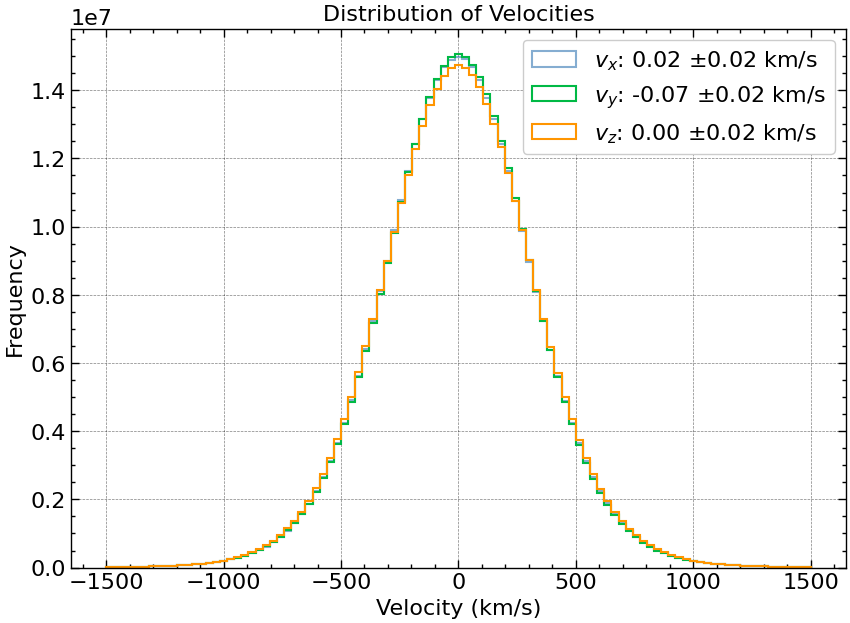

In [ ]:
bins = np.linspace(-1500, 1500, 100)
plt.figure(figsize=(10,7))
plt.hist(vel[:,0],bins=bins,alpha=0.5,label=f'$v_x$: {np.mean(vel[:,0]):.2f}$\pm${np.std(vel[:,0])/np.sqrt(len(vel[:,0])):.2f} km/s',histtype='step',lw = 1.5)
plt.hist(vel[:,1],bins=bins,alpha=1,label=f'$v_y$: {np.mean(vel[:,1]):.2f}$\pm${np.std(vel[:,1])/np.sqrt(len(vel[:,1])):.2f} km/s',histtype='step',lw = 1.5)
plt.hist(vel[:,2],bins=bins,alpha=1,label=f'$v_z$: {np.mean(vel[:,2]):.2f}$\pm${np.std(vel[:,2])/np.sqrt(len(vel[:,2])):.2f} km/s',histtype='step',lw = 1.5)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Velocities')
plt.legend()
plt.show()

In [ ]:
unit = np.sum(rhat,axis=1)

array([-1.7319744, -1.7319695, -1.7319194, ...,  1.7317622,  1.7317568,
        1.731823 ], dtype=float32)

In [67]:
rhat[0][0]**2 + rhat[0][1]**2 + rhat[0][2]**2

1.0000000357418806

In [74]:
pos - BOX/2

array([[-998.9478 , -999.8895 , -979.63586],
       [-998.7828 , -999.8492 , -978.93915],
       [-999.5375 , -999.0536 , -973.4036 ],
       ...,
       [ 999.5176 ,  999.0386 ,  961.067  ],
       [ 999.9238 ,  999.46826,  961.1294 ],
       [ 999.5066 ,  999.1206 ,  965.32056]], dtype=float32)

In [75]:
v = np.linalg.norm(vel, axis=1)

In [83]:
print(np.mean(rhat, axis=0))

[ 0.04386491  0.02837445 -0.0004075 ]


In [82]:
rel = pos - BOX/2  #setting the observer to the center of the box
r   = np.linalg.norm(rel, axis=1)  #estimating the radial distance of the halos from the observer
#estimating the angular position of the halos in the sky
dec = np.degrees(np.arcsin(rel[:,2]/r))   
ra  = np.degrees(np.arctan2(rel[:,1], rel[:,0])) % 360
z_cosmo   = z_of_Dc(r)  #getting the cosmological redshift of the halos from the observer
rhat = rel / r[:,None]   #unit vector along the line of sight from the observer to the halos
v_los = np.sum(vel * rhat, axis=1)      # velocity along the line of sight (LOS) in km/s, v_los = v.\hat{r}, where \hat{r} is the unit vector along the line of sight from the observer to the halos
z_obs = z_cosmo + (1 + z_cosmo) * v_los / CKMS  # observed redshift taking into account the Doppler effect due to the line-of-sight velocity of the halos
radial = z_obs < 0.15   

ra, dec = ra[radial], dec[radial]
rw = np.where(ra>180, ra-360, ra)

mask_full = np.load('/user/animesh.sah/DESI_PECVEL/mask_psf_full.npy')
nside = hp.get_nside(mask_full)
theta = np.radians(90.0 - dec)
phi   = np.radians(ra)
pix   = hp.ang2pix(nside, theta, phi)
in_footprint = mask_full[pix] > 0

# completeness = mask_full[pix]
# rng = np.random.default_rng(42)
# in_footprint = rng.random(len(pix)) < completeness


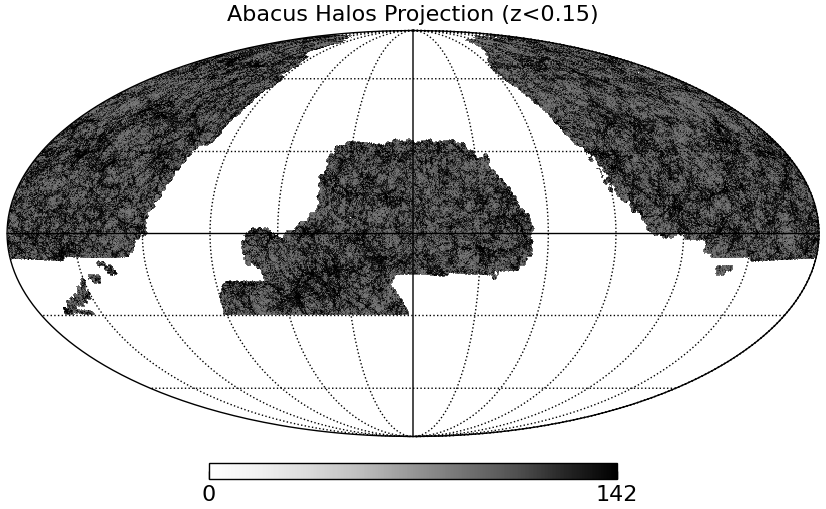

In [13]:
rw_in = rw[in_footprint]
dec_in = dec[in_footprint]
theta = np.radians(90.0 - dec_in)
phi   = np.radians(rw_in)
map = points_to_map(rw_in, dec_in, nside=256)
hp.mollview(map,   norm='hist', cmap='Greys', title='Abacus Halos Projection (z<0.15)')
hp.graticule()
plt.show()

In [14]:
print('% of objects with z obs < 0.15: {:.2f}%'.format((np.count_nonzero(radial)/len(z_obs)) * 100))
print('% of objects in the footprint: {:.2f}%'.format((np.count_nonzero(in_footprint)/len(rw)) * 100))
print('% of objects with z obs < 0.15 and in the footprint: {:.2f}%'.format((np.count_nonzero(in_footprint)/len(z_obs)) * 100))

% of objects with z obs < 0.15: 4.27%
% of objects in the footprint: 40.72%
% of objects with z obs < 0.15 and in the footprint: 1.74%


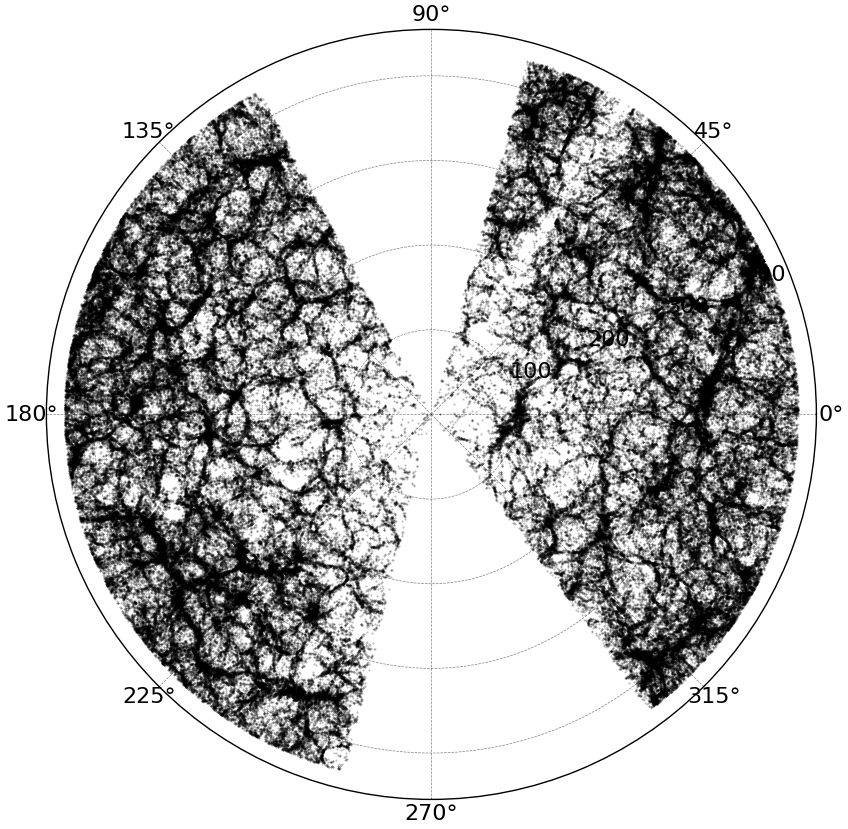

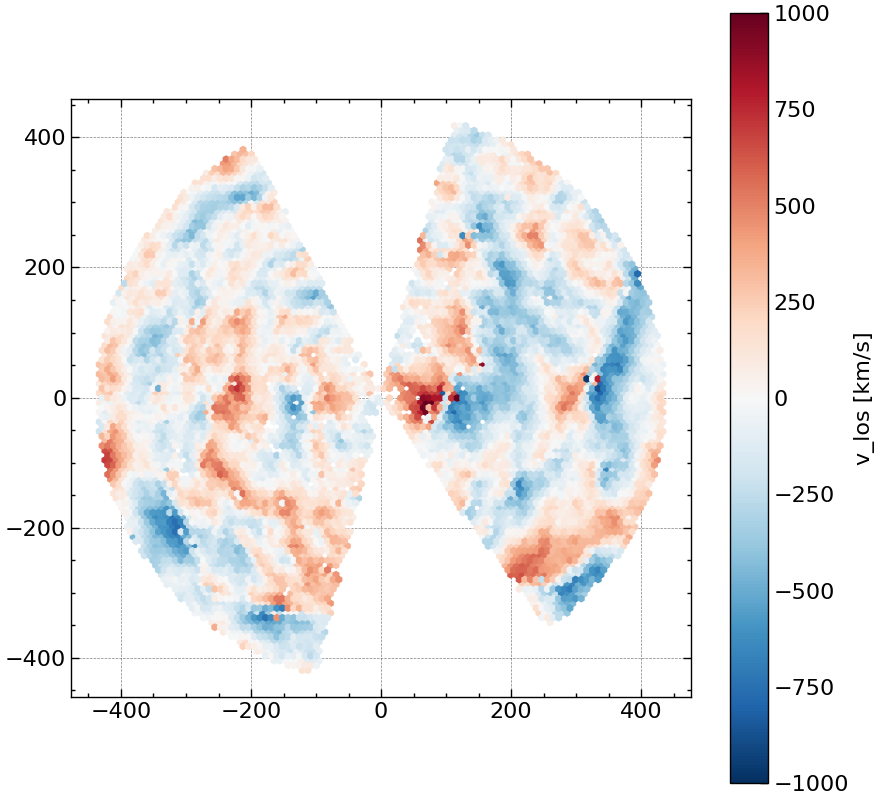

In [42]:
sl = np.abs(dec_in) < 2         # thin declination wedge
z_obs_new = z_obs[radial]              
r_com = cosmo.comoving_distance(z_obs_new[in_footprint][sl]).value * h
th = np.radians(rw_in[sl])

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='polar')
ax.scatter(th, r_com, s=0.2, alpha=0.3, c='k')
ax.set_thetamin(0); ax.set_thetamax(360)
plt.show()

#v_los_new = v_los[radial][in_footprint][sl]

plt.figure(figsize=(10,10))
# sc = plt.scatter(r_com*np.cos(np.radians(rw_in[sl])),
#                  r_com*np.sin(np.radians(rw_in[sl])),c=v_los[radial][in_footprint][sl], cmap='RdBu_r',marker=',', s=0.2, vmin=-1000, vmax=1000)

sc = plt.hexbin(r_com*np.cos(np.radians(rw_in[sl])),
                 r_com*np.sin(np.radians(rw_in[sl])),C=v_los[radial][in_footprint][sl], cmap='RdBu_r', gridsize=100, reduce_C_function=np.median, vmin=-1000, vmax=1000)
plt.colorbar(sc, label='v_los [km/s]')
plt.gca().set_aspect('equal')
plt.show()

In [39]:
y_positive = r_com*np.sin(np.radians(rw_in[sl]))>0
y_negative = r_com*np.sin(np.radians(rw_in[sl]))<0
x_negative = r_com*np.cos(np.radians(rw_in[sl]))<0
x_positive = r_com*np.cos(np.radians(rw_in[sl]))>0


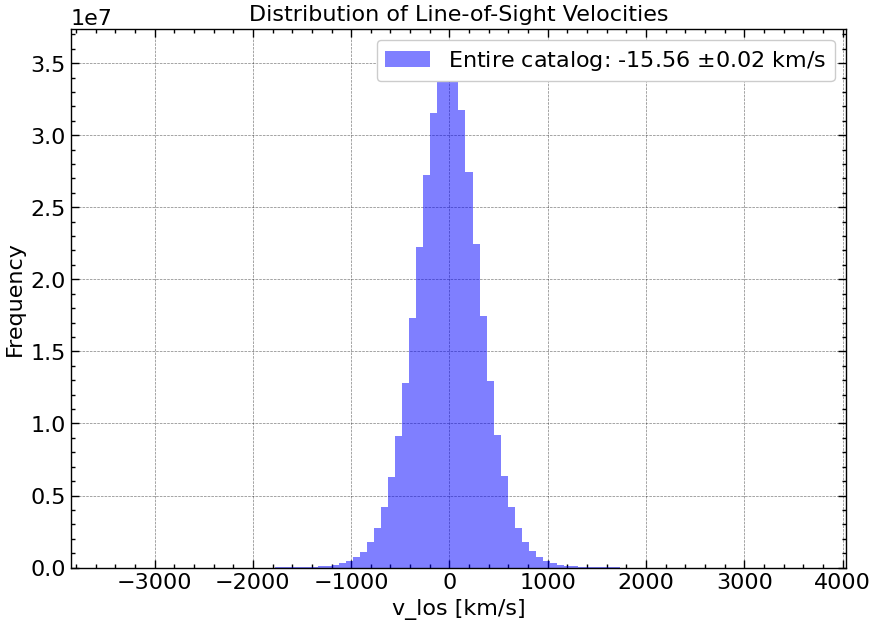

In [58]:
plt.figure(figsize=(10,7))
plt.hist(v_los,bins = 100, alpha=0.5,  color='blue',label = f'Entire catalog: {np.mean(v_los):.2f} $\pm${np.std(v_los)/np.sqrt(len(v_los)):.2f} km/s')
plt.xlabel('v_los [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Line-of-Sight Velocities')
plt.legend()
plt.show()

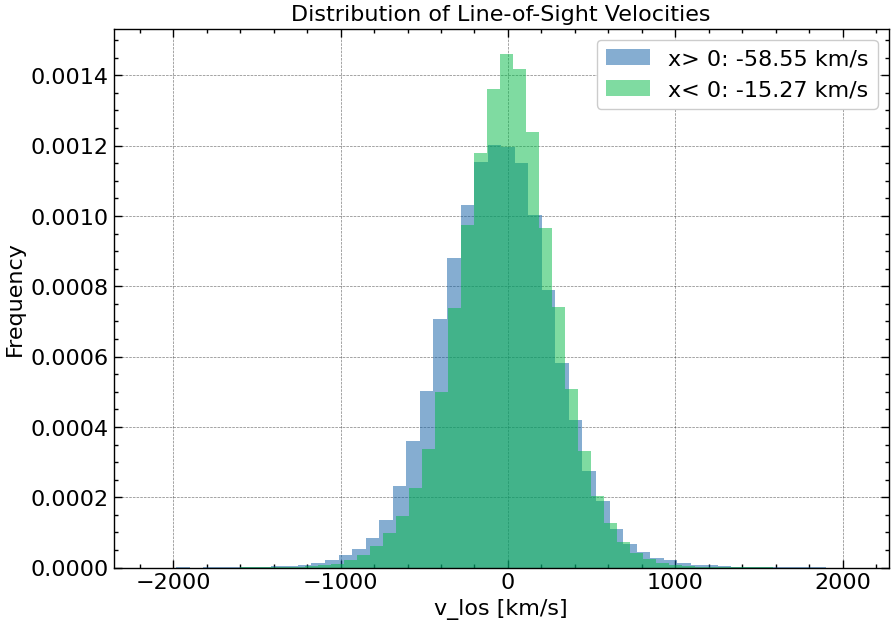

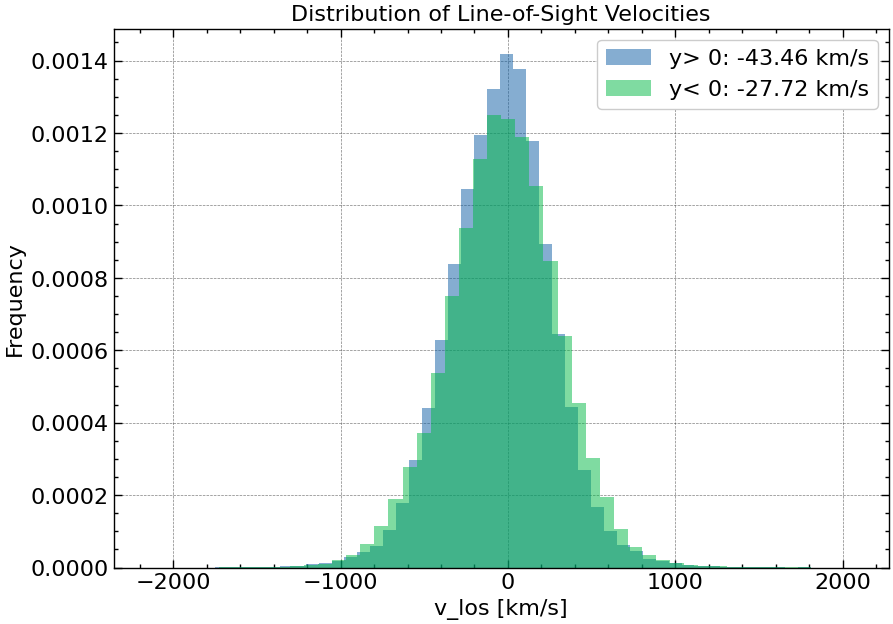

In [40]:
plt.figure(figsize=(10,7))
plt.hist(v_los[radial][in_footprint][sl][x_positive],bins=50,alpha = 0.5,label=f'x> 0: {np.mean(v_los[radial][in_footprint][sl][x_positive]):.2f} km/s',density=True)
plt.hist(v_los[radial][in_footprint][sl][x_negative],bins=50,alpha = 0.5,label=f'x< 0: {np.mean(v_los[radial][in_footprint][sl][x_negative]):.2f} km/s',density=True)
plt.xlabel('v_los [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Line-of-Sight Velocities')
plt.legend()

plt.figure(figsize=(10,7))
plt.hist(v_los[radial][in_footprint][sl][y_positive],bins=50,alpha = 0.5,label=f'y> 0: {np.mean(v_los[radial][in_footprint][sl][y_positive]):.2f} km/s',density=True)
plt.hist(v_los[radial][in_footprint][sl][y_negative],bins=50,alpha = 0.5,label=f'y< 0: {np.mean(v_los[radial][in_footprint][sl][y_negative]):.2f} km/s',density=True)
plt.xlabel('v_los [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Line-of-Sight Velocities')
plt.legend()

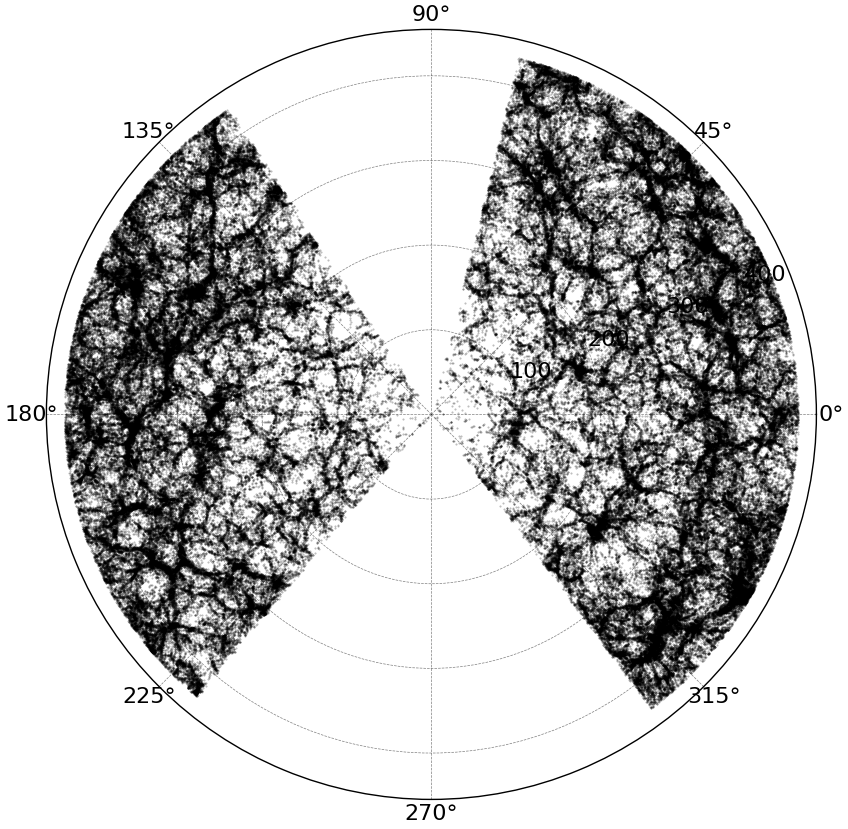

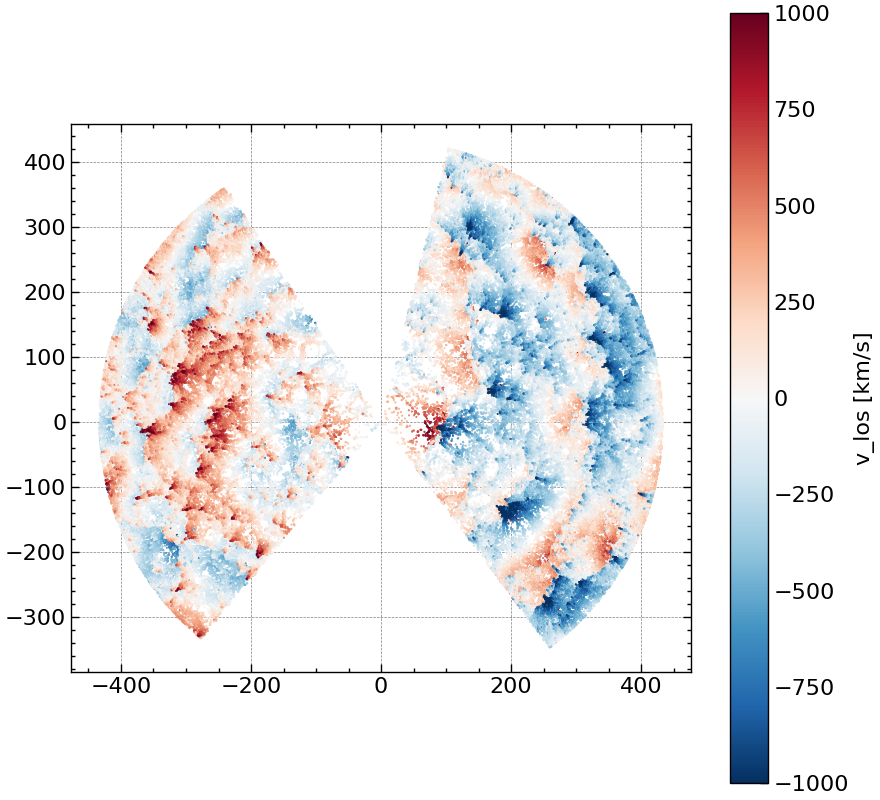

In [15]:
sl = np.abs(dec_in+5) < 2         # thin declination wedge
z_obs_new = z_obs[radial]              
r_com = cosmo.comoving_distance(z_obs_new[in_footprint][sl]).value * h
th = np.radians(rw_in[sl])

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='polar')
ax.scatter(th, r_com, s=0.2, alpha=0.3, c='k')
ax.set_thetamin(0); ax.set_thetamax(360)
plt.show()

#v_los_new = v_los[radial][in_footprint][sl]

plt.figure(figsize=(10,10))
sc = plt.scatter(r_com*np.cos(np.radians(rw_in[sl])),
                 r_com*np.sin(np.radians(rw_in[sl])),c=v_los[radial][in_footprint][sl], cmap='RdBu_r', s=0.2, vmin=-1000, vmax=1000)
plt.colorbar(sc, label='v_los [km/s]')
plt.gca().set_aspect('equal')
plt.show()

In [21]:
from matplotlib.animation import FuncAnimation
from scipy.spatial import cKDTree

In [17]:
nframes = 100
thick = 20
z_centers = np.linspace(0, BOX, nframes)
sub = np.random.default_rng(0).random(len(pos)) < 0.05
p = pos[sub]

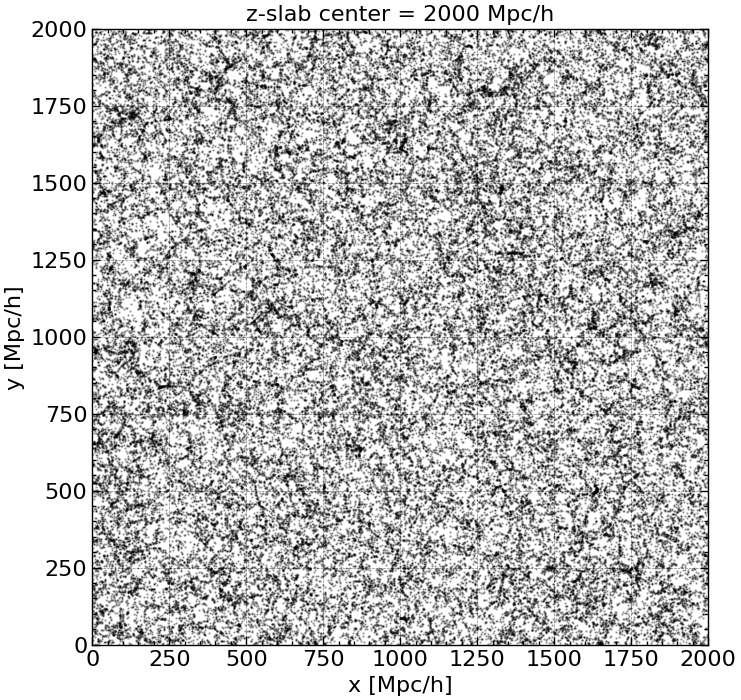

In [24]:
fig, ax = plt.subplots(figsize=(8,8))
scat = ax.scatter([], [], s=0.5, c='k', alpha=0.3)
ax.set_xlim(0, BOX); ax.set_ylim(0, BOX); ax.set_aspect('equal')
ax.set_xlabel('x [Mpc/h]'); ax.set_ylabel('y [Mpc/h]')
title = ax.set_title('')

def update(i):
    zc = z_centers[i]
    m = np.abs(p[:,2] - zc) < thick/2
    scat.set_offsets(p[m][:, :2])
    title.set_text(f'z-slab center = {zc:.0f} Mpc/h')
    return scat, title

anim = FuncAnimation(fig, update, frames=nframes, interval=80, blit=False)
anim.save('slab_sweep.gif', writer='pillow', fps=15)   # needs ffmpeg

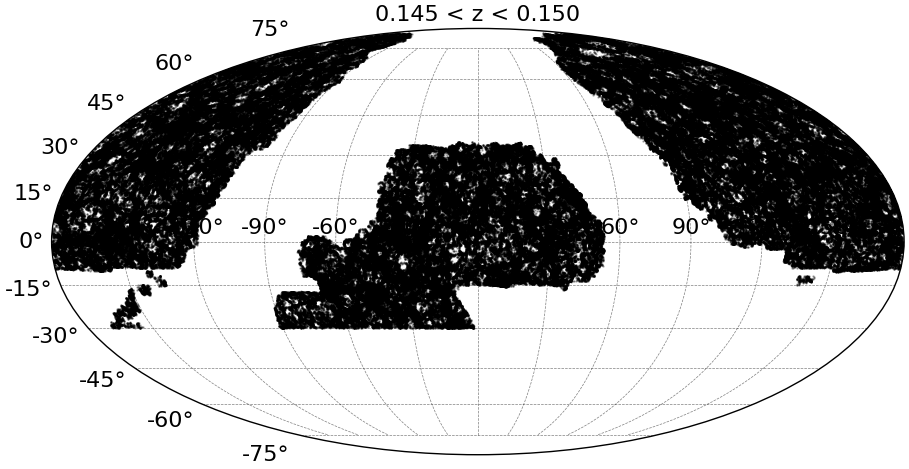

In [27]:
zmin, zmax, dz = 0.0, 0.15, 0.005
z_lo = np.arange(zmin, zmax, dz)
ra_wrap = np.where(rw_in>180, rw_in-360, rw_in)
fig = plt.figure(figsize=(11,6))
ax = fig.add_subplot(111, projection='mollweide')
scat = ax.scatter([], [], s=0.5, c='k', alpha=0.3)
ax.grid(True)
title = ax.set_title('')
def update(i):
    lo = z_lo[i]
    m = (z_obs_new[in_footprint] > lo) & (z_obs_new[in_footprint] < lo+dz)
    xy = np.column_stack([np.radians(-ra_wrap[m]), np.radians(dec_in[m])])
    scat.set_offsets(xy)
    title.set_text(f'{lo:.3f} < z < {lo+dz:.3f}')
    return scat, title
anim = FuncAnimation(fig, update, frames=len(z_lo), interval=120)
anim.save('shell_sweep.gif', writer='pillow', dpi=120, fps=8)

In [35]:
rel[6491368]

array([-954.27374, -586.6272 ,    0.     ], dtype=float32)

In [44]:
rel[161426232]

array([-1.1282959,  0.6616821,  0.7214966], dtype=float32)

In [49]:
print(f'{len(z_obs_new[in_footprint]):,}')

6,648,359


In [43]:
idx = np.where(r < 1.5)[0]         # effectively at the observer
idx

array([161426232])

In [32]:
rhat = rel / r[:,None]
v_los = np.sum(vel * rhat, axis=1)      # km/s along LOS
z_obs = z_cosmo + (1 + z_cosmo) * v_los / CKMS

In [44]:
zmin, zmax = 0.0, 0.15
radial = (z_obs > zmin) & (z_obs < zmax)

In [58]:
mask_full = np.load('/user/animesh.sah/DESI_PECVEL/mask_psf_full.npy')
nside = hp.get_nside(mask_full)
theta = np.radians(90.0 - dec)
phi   = np.radians(ra)
pix   = hp.ang2pix(nside, theta, phi)
in_footprint = mask_full[pix] > 0


In [59]:
completeness = mask_full[pix]
rng = np.random.default_rng(42)
in_footprint = rng.random(len(pix)) < completeness


In [60]:
selection = radial & in_footprint
mock = d[selection]

Clustering  based on mass

In [8]:
d['Mvir']

array([1.6582443e+11, 1.7898509e+11, 1.5792803e+11, ..., 1.7372083e+11,
       8.3701852e+11, 6.6856197e+11], dtype=float32)